## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv("Student Mental health.csv")
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


### Missing Values

In [3]:
df.isnull().sum() / len(df) * 100

Timestamp                                       0.000000
Choose your gender                              0.000000
Age                                             0.990099
What is your course?                            0.000000
Your current year of Study                      0.000000
What is your CGPA?                              0.000000
Marital status                                  0.000000
Do you have Depression?                         0.000000
Do you have Anxiety?                            0.000000
Do you have Panic attack?                       0.000000
Did you seek any specialist for a treatment?    0.000000
dtype: float64

### Shape

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (101, 11)


### Column Names

In [5]:
print(df.columns.tolist())

['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


### Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

### Null Count

In [7]:
print(df.isnull().sum())

Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64


In [8]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_13916\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


### Duplicate Rows

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df.describe()

,Age
count,101.000000
mean,20.530000
std,2.483767
min,18.000000
25%,18.000000
50%,19.000000
75%,23.000000
max,24.000000


### Separate Columns

In [11]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", cat_cols.tolist())
print("Numerical columns:", num_cols.tolist())

Categorical columns: ['Timestamp', 'Choose your gender', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']
Numerical columns: ['Age']


### Drop Useless Columns

In [12]:
df = df.drop(columns=["Timestamp"])
df.head()

,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


### Target Distribution

In [13]:
df["Do you have Depression?"].value_counts()

Do you have Depression?
No     66
Yes    35
Name: count, dtype: int64

### Depression Graph

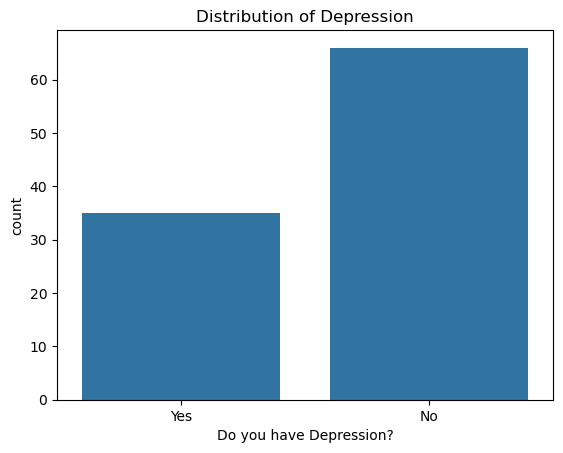

In [14]:
sns.countplot(x="Do you have Depression?", data=df)
plt.title("Distribution of Depression")
plt.show()

### Outliers

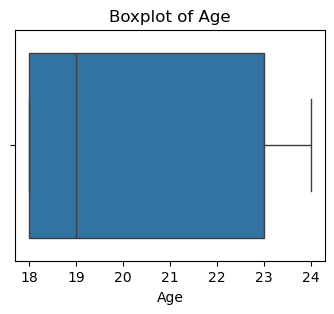

In [15]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Gender Distribution

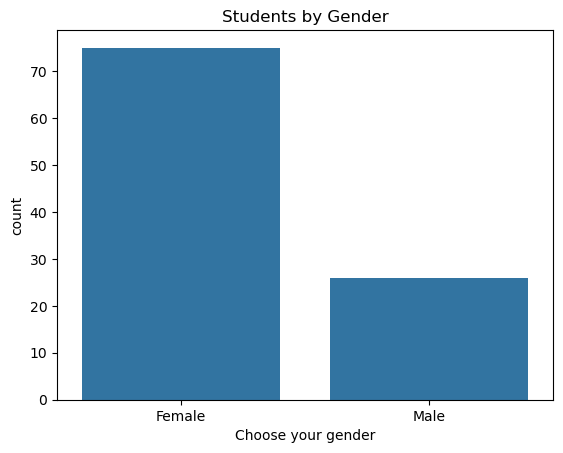

In [16]:
sns.countplot(x="Choose your gender", data=df)
plt.title("Students by Gender")
plt.show()

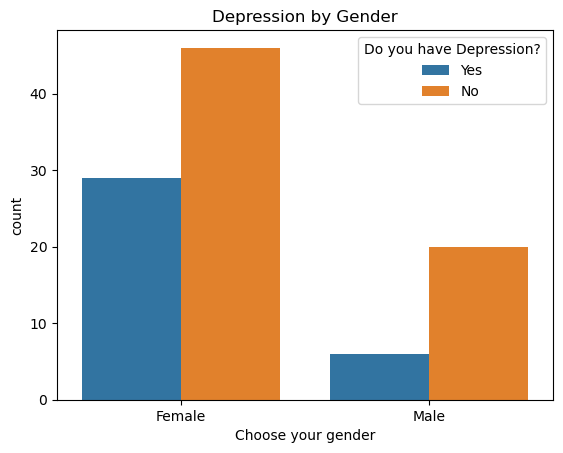

In [17]:
sns.countplot(x="Choose your gender", hue="Do you have Depression?", data=df)
plt.title("Depression by Gender")
plt.show()

### Encoding + Correlation

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
corr = df_encoded.corr()

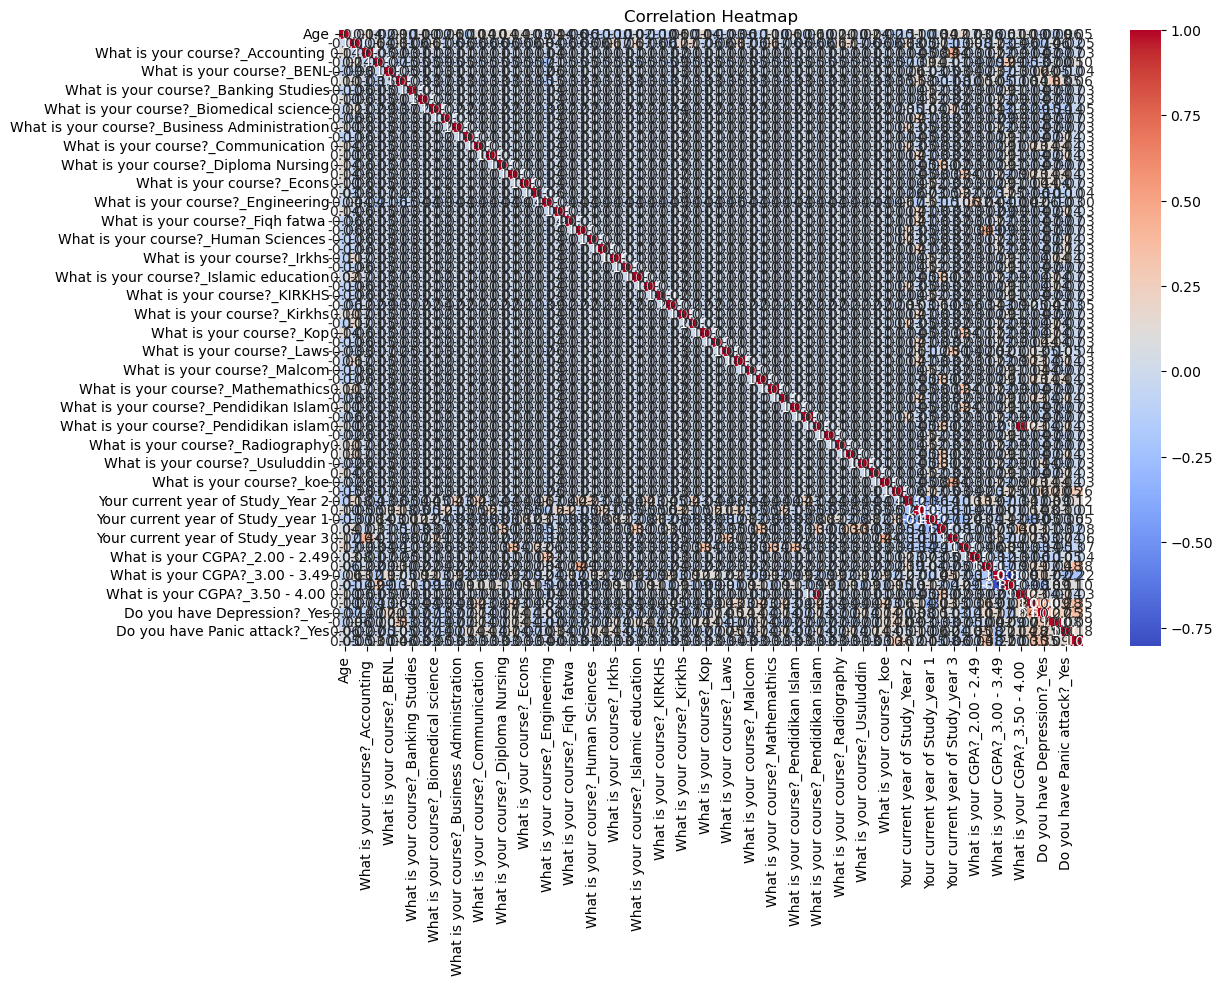

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Preprocessing

### Split X & y

In [20]:
X = df.drop("Do you have Depression?", axis=1)
y = df["Do you have Depression?"]

print(X.head())
print(y.head())

  Choose your gender   Age What is your course? Your current year of Study  \
0             Female  18.0          Engineering                     year 1   
1               Male  21.0    Islamic education                     year 2   
2               Male  19.0                  BIT                     Year 1   
3             Female  22.0                 Laws                     year 3   
4               Male  23.0         Mathemathics                     year 4   

  What is your CGPA? Marital status Do you have Anxiety?  \
0        3.00 - 3.49             No                   No   
1        3.00 - 3.49             No                  Yes   
2        3.00 - 3.49             No                  Yes   
3        3.00 - 3.49            Yes                   No   
4        3.00 - 3.49             No                   No   

  Do you have Panic attack? Did you seek any specialist for a treatment?  
0                       Yes                                           No  
1                   

In [21]:
X = pd.get_dummies(X, drop_first=True)
print(X.head())

    Age  Choose your gender_Male  What is your course?_Accounting   \
0  18.0                    False                             False   
1  21.0                     True                             False   
2  19.0                     True                             False   
3  22.0                    False                             False   
4  23.0                     True                             False   

   What is your course?_BCS  What is your course?_BENL  \
0                     False                      False   
1                     False                      False   
2                     False                      False   
3                     False                      False   
4                     False                      False   

   What is your course?_BIT  What is your course?_Banking Studies  \
0                     False                                 False   
1                     False                                 False   
2                      

### Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (80, 65)
Testing size: (21, 65)


### Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))
print("Classification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7619047619047619
Confusion Matrix
[[12  1]
 [ 4  4]]
Classification Report
              precision    recall  f1-score   support

          No       0.75      0.92      0.83        13
         Yes       0.80      0.50      0.62         8

    accuracy                           0.76        21
   macro avg       0.78      0.71      0.72        21
weighted avg       0.77      0.76      0.75        21



## Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.9047619 0.8       0.85      0.75      0.8      ]
Average CV Score: 0.8209523809523811


In [28]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7142857142857143
Confusion Matrix
[[12  1]
 [ 5  3]]
Classification Report
              precision    recall  f1-score   support

          No       0.71      0.92      0.80        13
         Yes       0.75      0.38      0.50         8

    accuracy                           0.71        21
   macro avg       0.73      0.65      0.65        21
weighted avg       0.72      0.71      0.69        21



In [30]:
import pickle
pickle.dump(rf_model, open("mental_health_model.pkl", "wb"))